In [34]:
import os
import json
import time
import threading
import psutil
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from memory_profiler import memory_usage
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import f1_score,  confusion_matrix
import joblib
from keras.models import load_model
import shap
import xgboost as xgb
import pandas as pd

# loading processed dataset

In [35]:
with open('../config/preprocessing_df_config.json', 'r') as f:
    config = json.load(f)

In [36]:
dataset_folder = '../dataset'
df = pd.read_parquet(os.path.join(dataset_folder, 'final_test_dataset_processed.parquet'))
attack_labels_df = df[['Label',"Label_Category"]]
df = df.drop(columns=config['columns_to_drop'])

# functions

In [37]:
# 1. Dynamic Custom Scorer Factory
def get_custom_scorer(contamination):
    """Generates a custom scoring function based on the dataset's contamination rate."""
    def custom_score(estimator, X, y):
        # The pipeline's decision_function will call the IsolationForest's decision_function
        anomaly_scores = estimator.decision_function(X)
        threshold = np.percentile(anomaly_scores, 100 * (1 - contamination))
        
        y_pred = (anomaly_scores <= threshold).astype(int)
        return f1_score(y, y_pred, pos_label=1, average='binary')
    
    return custom_score

In [38]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, f1_score

def compute_roc(y_true, y_scores):
    """
    Computes ROC curve and AUC from the true labels and predicted scores.
    
    Parameters:
    y_true (list or array): True binary labels (0 or 1)
    y_scores (list or array): Predicted probability scores
    
    Returns:
    fpr: False positive rate
    tpr: True positive rate
    roc_auc: Area under the ROC curve
    """
    # Compute FPR, TPR, and thresholds using sklearn's roc_curve
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    
    # Compute the AUC (Area Under the Curve)
    roc_auc = auc(fpr, tpr)
    
    return fpr, tpr, roc_auc


def plot_roc_curve(fpr, tpr, roc_auc, title=None):
    """
    Plots the ROC curve with the given FPR, TPR and AUC.
    
    Parameters:
    fpr: False positive rate
    tpr: True positive rate
    roc_auc: Area under the ROC curve
    title: Title of the plot (optional)
    """
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', linestyle='--')  # Diagonal line
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title if title else 'Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()


def compute_pr_auc(y_true, y_scores):
    """
    Computes Precision-Recall curve and AUC from true labels and predicted scores.
    
    Parameters:
    y_true (list or array): True binary labels (0 or 1)
    y_scores (list or array): Predicted probability scores
    
    Returns:
    precision: Precision values
    recall: Recall values
    pr_auc: Area under the Precision-Recall curve
    """
    # Compute precision, recall, and thresholds using sklearn's precision_recall_curve
    precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
    
    # Compute the AUC (Area Under the Curve) for precision-recall
    pr_auc = auc(recall, precision)
    
    return precision, recall, pr_auc, thresholds


def plot_pr_curve(precision, recall, pr_auc, title=None):
    """
    Plots the Precision-Recall curve with the given precision, recall, and AUC.
    
    Parameters:
    precision: Precision values
    recall: Recall values
    pr_auc: Area under the Precision-Recall curve
    title: Title of the plot (optional)
    """
    plt.figure()
    plt.plot(recall, precision, color='blue', lw=2, label=f'PR curve (AUC = {pr_auc:.4f})')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(title if title else 'Precision-Recall Curve')
    plt.legend(loc="lower left")
    plt.show()

In [39]:
def fit_pipeline_with_resources(pipeline, X_train, random_state=42):
    """Trains a pipeline while tracking memory, time, and CPU usage."""
    measurement = {}

    cpu_usage = []
    stop_flag = threading.Event()

    def monitor_cpu():
        while not stop_flag.is_set():
            cpu_usage.append(psutil.cpu_percent(interval=0.1))

    def train_model():
        pipeline.fit(X_train)

    try:
        cpu_thread = threading.Thread(target=monitor_cpu)
        cpu_thread.start()

        start_time = time.time()
        # Measure peak memory usage during the pipeline.fit execution
        train_memory = max(memory_usage((train_model,))) 
        training_time = time.time() - start_time

        stop_flag.set()
        cpu_thread.join()

        measurement['Memory Usage (MB)'] = train_memory
        measurement['Training Time (s)'] = training_time
        measurement['Peak CPU Usage (%)'] = max(cpu_usage) if cpu_usage else 0
        measurement['Average CPU Usage (%)'] = sum(cpu_usage) / len(cpu_usage) if cpu_usage else 0

        return measurement, pipeline

    except Exception as e:
        print(f"Error during pipeline training: {e}")
        stop_flag.set()
        return None, None

# Loading models

In [40]:
pipeline_filename_if1 = '../models/if_iter1.joblib'
pipeline_filename_if2 = '../models/if_iter2.joblib'
pipeline_filename_ae1 = '../models/ann-iter1-2.keras'
pipeline_filename_ae2 = '../models/ann-iter2-2.keras'
pipeline_filename_xgb = '../models/xgb.joblib'

# Export the pipeline to a file
model_if1 = joblib.load(pipeline_filename_if1)
model_if2 = joblib.load(pipeline_filename_if2)
model_ae1 = load_model(pipeline_filename_ae1)
model_ae2 = load_model(pipeline_filename_ae2)
model_xgb = joblib.load(pipeline_filename_xgb)

In [41]:
scaler_filename = '../config/standard_scaler.joblib'
scaler = joblib.load(scaler_filename)

# Explainability

## train test split
test split was done during initial EDA and preprocessing

In [42]:
# Preparing features and truth labels
X_test = df.drop(['Label','anomaly','Label_Category'], axis=1)
y_test = df['anomaly']

## scaling

In [43]:
X_test_scaled = scaler.transform(X_test)

## model wrapper

In [68]:
xgb_model = model_xgb.named_steps['model']

booster = xgb_model.get_booster()

def predict_fn(X):
    return xgb_model.predict_proba(X)[:, 1]

In [ ]:
background_data = pd.DataFrame(X_test_scaled, columns=X_test.columns).sample(100, random_state=42)

In [71]:
explainer = shap.KernelExplainer(predict_fn, background_data)

In [72]:
X_sample = X_test.sample(50, random_state=42)

shap_values = explainer.shap_values(X_sample)

100%|██████████| 50/50 [00:43<00:00,  1.15it/s]


In [73]:
shap_exp = shap.Explanation(
    values=shap_values,
    data=X_sample.values,
    feature_names=X_sample.columns
)

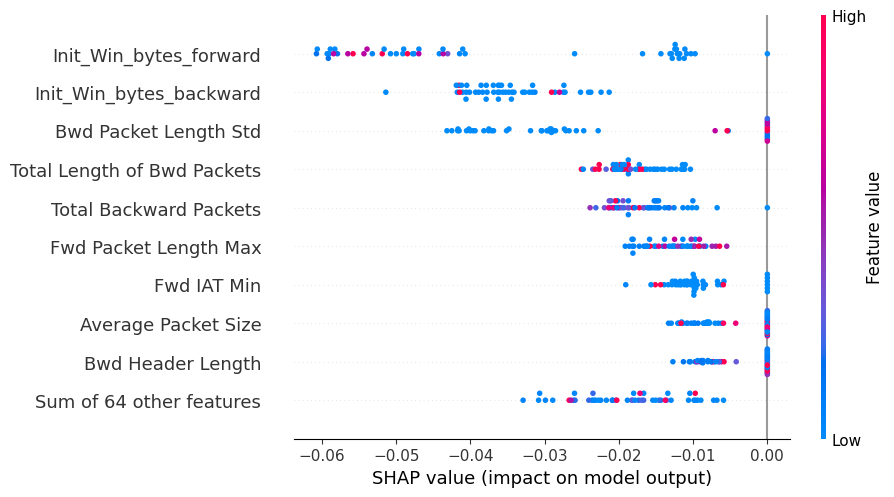

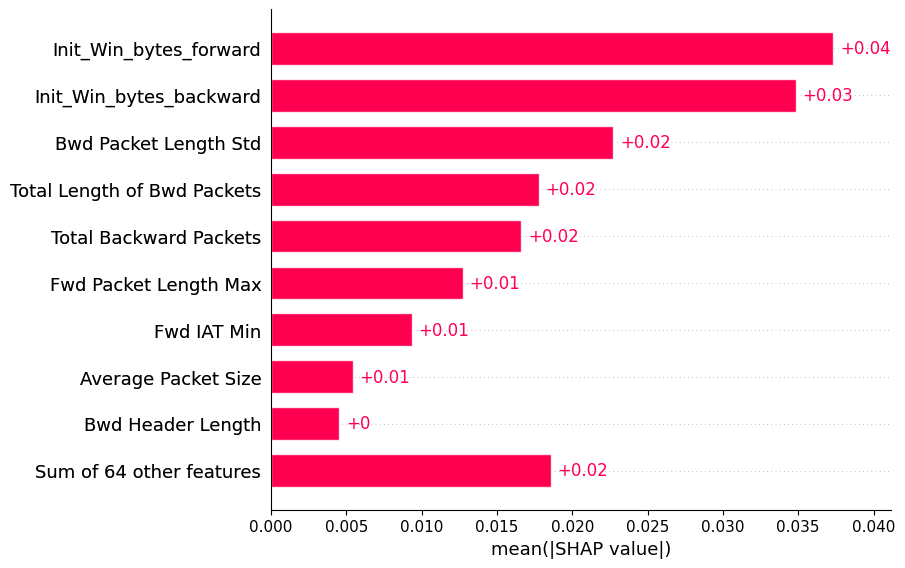

In [74]:
shap.plots.beeswarm(shap_exp)
shap.plots.bar(shap_exp)

Top Feature Interpretations
1. Initial Window Bytes (Forward & Backward)
    
    Init_Win_bytes_forward and Init_Win_bytes_backward are your most influential features.

- The Trend: Both high (pink) and low (blue) values are pushing the prediction negative.
- The Context: In network traffic, the initial window size is often determined by the Operating System's TCP stack. Specific window sizes are highly characteristic of standard, "clean" handshakes. If your model sees a standard window size (like 8192 or 65535), it’s a strong "Benign" signal.

2. Bwd Packet Length Std

    This measures the variation in the size of packets coming back from the destination.

- The Trend: Lower values (blue) have a significant negative SHAP impact.
- The Context: Benign traffic often follows predictable patterns (like a standard HTTP response). Low variability in packet length suggests a consistent, non-erratic flow, which the model interprets as a sign of safety.

3. Fwd IAT Min (Forward Inter-Arrival Time Minimum)

    This is the minimum time between two packets sent in the forward direction.

- The Trend: Most data points are clustered between −0.01 and −0.02.
- The Context: Very small or very consistent inter-arrival times can sometimes flag automated bot behavior, but here, the distribution suggests that the "normal" timing of these packets is helping the model confirm the traffic is not an attack.

4. Average Packet Size & Bwd Header Length

These features are behaving similarly, with points clustered near the −0.01 mark. This suggests they are "supporting" features—they don't radically change the model's mind on their own, but they provide consistent evidence for the final classification.

The SHAP beeswarm plot for the XGBoost classifier reveals that Init_Win_bytes_forward, Init_Win_bytes_backward, and Bwd Packet Length Std are the top features driving the model’s anomaly predictions. High and low feature values generally push predictions toward normal, though some features show non-linear effects. The plot confirms that a small subset of features dominates the model’s decisions, while the majority contribute minimally. For ethical AI analysis, mean SHAP values across simulated flow types (e.g., TCP vs UDP) can reveal potential model biases toward specific traffic characteristics, guiding fairness audits and mitigation strategies.

# Addressing Limitations

## Class Imbalance
CICIDS2017 is highly imbalanced—benign traffic dominates while some attack types have very few samples. This causes the model to favor the majority class, leading to poor detection of rare attacks (high false negatives).

For class imbalance, this was mitigated by our PR-AUC, Precision, Recall, F1-Score metrics that deals with imbalanced dataset. But for model development, conveniently XGBoost has parameter scale_pos_weight which you can set to take into account class imbalances for classification problems

## Data Leakage
If the model “sees” features from the future or features that are derived from the target, it can overestimate performance.

This was mitigated by making sure labels or columns feature engineered from labels were dropped before training. Another is fitting scalers and encoders only on training data then transforming it on our test and validation

## Overfitting
XGBoost, like other tree ensemble models, can easily memorize training data especially with high dimension like CICIDS217.

This was mitigated by model regularization by limiting possible values on hyperparameter tuning, like max depth, min child weight, colsample bytree, subsample, etc. Stratified KFold was also used to ensure minority classes are represented in each fold.

With the risk of overfitting due to high dimensions, we implemented feature selection via various methods such as variance analysis, correlation analysis, finding duplicates, feature importance, PCA, etc. during initial EDA and pre-processing of our data.

# Bias detection & fairness audits

1. IS fairness/bias in IDS relevant? In traditional machine learning (like credit scoring or hiring), fairness focuses on sensitive human groups (gender, race, age). In an IDS, the “target” is usually malicious vs benign traffic. But by getting creative, we can still extend the idea of bias in IDS

Traffic source: different subnet, group, or country may generate traffic differently and if IDS is more likely to flag one's group as malicious, it could create operational unfaireness.

But with our available data, it is not possible to test it.

But in case that the data is available, we can propose steps to apply faireness audits:
1. Define groups by traffic context (source IP, device type, protocol)
2. Measure group-level metrics
3. Fairness metrics analogs: Equal detection rate across network groups
4. Mitigation: Oversample or simulate rare/novel attacks in underrepresented groups or adjust thresholds per group